✅ Loaded: /content/data_f.xlsx
Shape: (2509, 33)
Columns: ['ticket_number', 'day', 'month', 'year', 'type_of_site', 'site', 'priority', 'sector', 'incident_time', 'severity_category', 'fault_alarmandactivity', 'team leader', 'persons_attended', 'need_spare_parts', 'maintenance_type', 'responsible_team', 'team_location', 'no_technicians_at_time_of_maintance', 'distance_to_site_km', 'need_cars', 'no_of_cars', 'technicians_count', 'time_in', 'time_out', 'downtime_hours', 'work_hours', 'labor_cost', 'parts_cost', 'SparePart_Action', 'inspection_result', 'risk_before_%', 'risk_after_%', 'under_warranty']

✅ Using Features:
NUM_COLS: ['no_technicians_at_time_of_maintance']
CAT_COLS: ['site', 'severity_category']
TEXT_COL: fault_alarmandactivity


,ticket_number,day,month,year,type_of_site,site,priority,sector,incident_time,severity_category,...,time_out,downtime_hours,work_hours,labor_cost,parts_cost,SparePart_Action,inspection_result,risk_before_%,risk_after_%,under_warranty
0,T_4982,9,1,2024,communication_site,r207,4,dawadmi,0.106944,minor,...,06:41:00,4,2011,10351.92,468.30,replaced,pass,25,0,yes
1,T_7120,1,3,2024,communication_site,r056,4,dawadmi,0.3875,minor,...,11:46:00,12,2649,6360.10,19450.87,replaced,pass,48,0,yes
2,T_8942,8,3,2024,communication_site,r151,4,muzahamiyah,0.540972,minor,...,11:22:00,11,2804,12367.12,4951.96,replaced,pass,20,0,yes
3,T_4544,11,1,2024,communication_site,r194,4,majmaah,0.484722,minor,...,14:44:00,4,2201,1830.43,18545.22,no_need,pass,23,0,yes
4,T_1729,2,4,2024,communication_site,r133,4,riyadh 1,0.540972,minor,...,17:16:00,7,1512,7541.51,16387.03,fixed,pass,55,0,yes



✅ Dataset Summary Table


,Column,Data Type,Missing Values,Missing %,Unique Values
0,ticket_number,object,0,0.00,2509
1,day,int64,0,0.00,31
2,month,int64,0,0.00,12
3,year,int64,0,0.00,2
4,type_of_site,object,0,0.00,9
5,site,object,0,0.00,259
6,priority,int64,0,0.00,4
7,sector,object,2,0.08,153
8,incident_time,object,0,0.00,426
9,severity_category,object,0,0.00,8


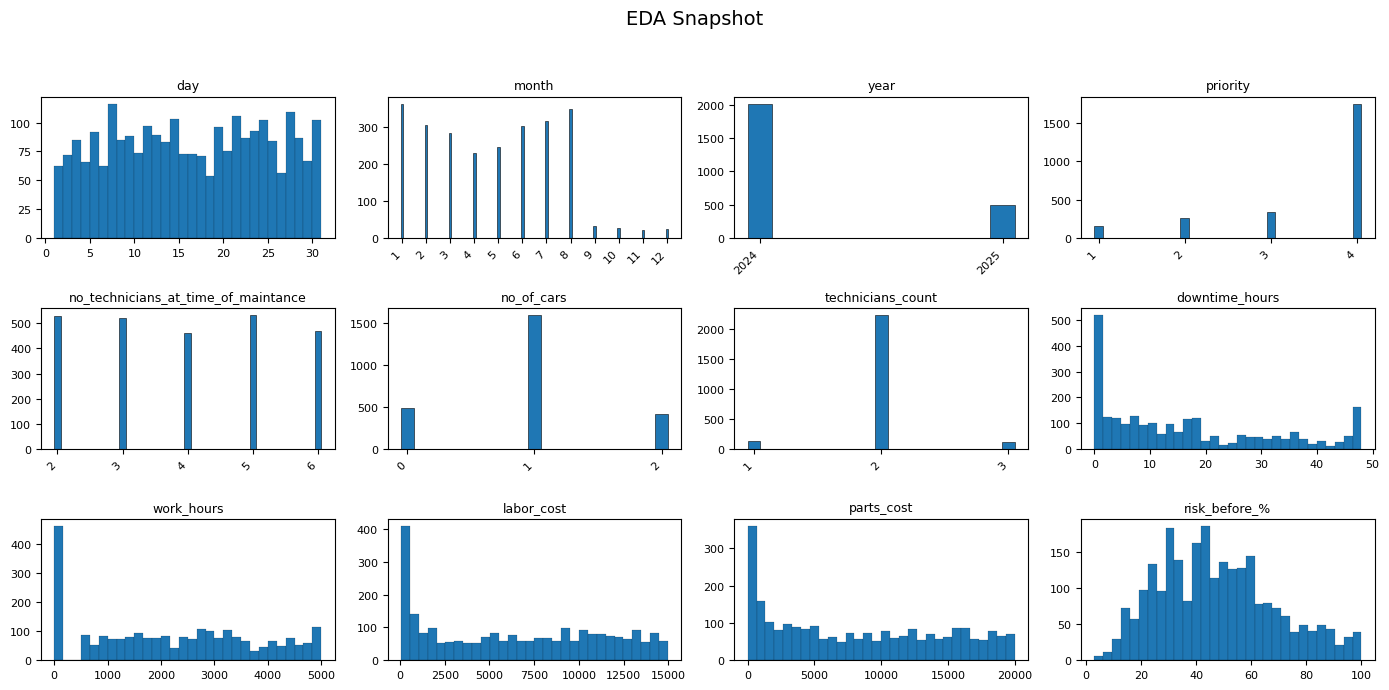

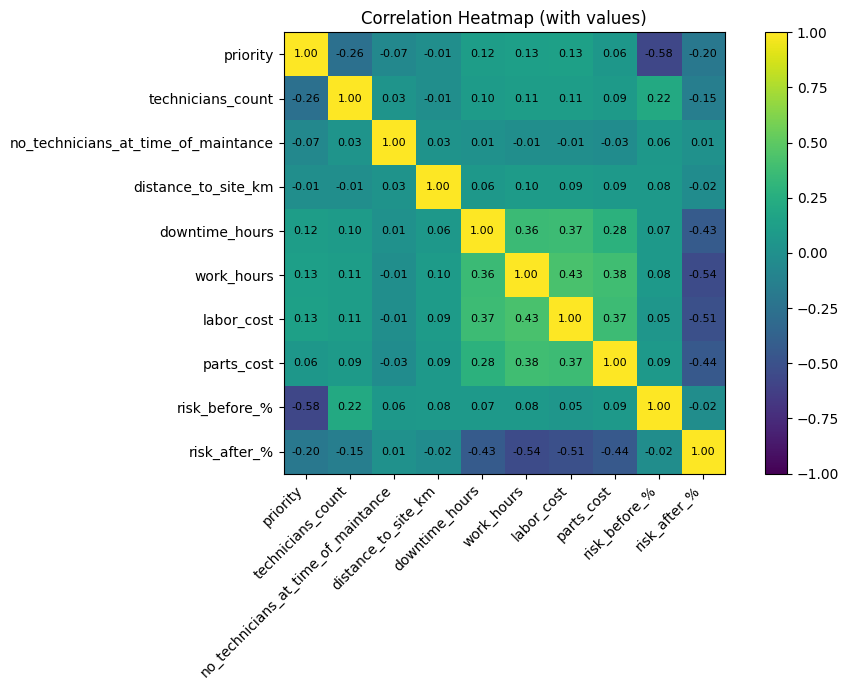


✅ Pre-training candidates:
Numeric cols: 13
Categorical cols: 16
Text col: fault_alarmandactivity

===== TOP 20 (TOP IMPORTANT FEATURES) for technicians_count =====


,feature,score,type
0,labor_cost,1.000000,numeric
1,site,1.000000,categorical
2,distance_to_site_km,0.998936,numeric
3,no_of_cars,0.967364,numeric
4,risk_before_%,0.949512,numeric
5,work_hours,0.930750,numeric
6,parts_cost,0.847686,numeric
7,downtime_hours,0.741446,numeric
8,year,0.705215,numeric
9,maintenance_type,0.668332,categorical



===== TOP 20 (TOP IMPORTANT FEATURES) for priority =====


,feature,score,type
0,distance_to_site_km,1.000000,numeric
1,site,1.000000,categorical
2,severity_category,0.895544,categorical
3,labor_cost,0.855761,numeric
4,risk_before_%,0.828102,numeric
5,work_hours,0.716309,numeric
6,parts_cost,0.676170,numeric
7,downtime_hours,0.562038,numeric
8,need_spare_parts,0.539907,categorical
9,incident_time,0.430495,numeric


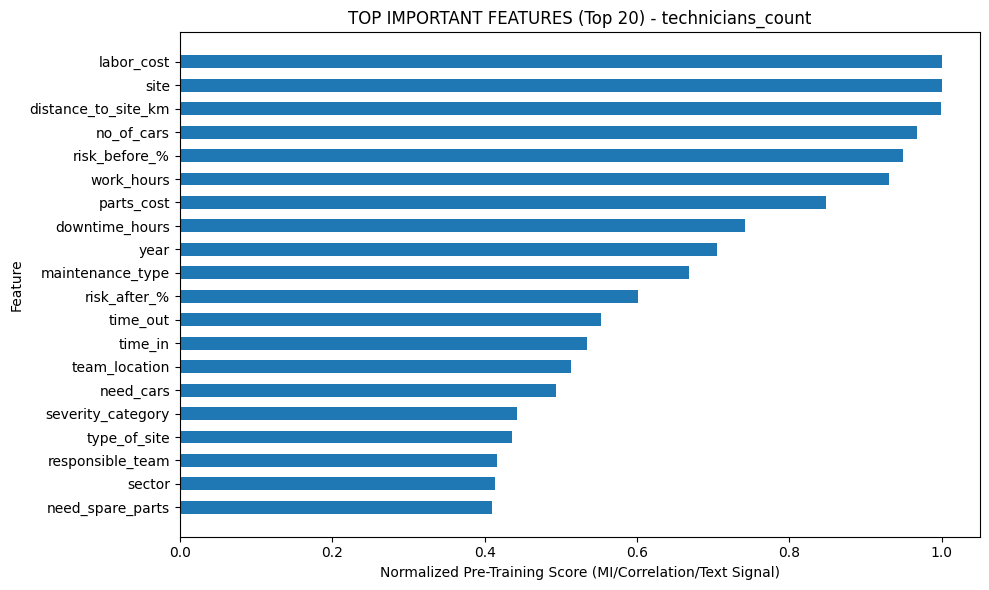

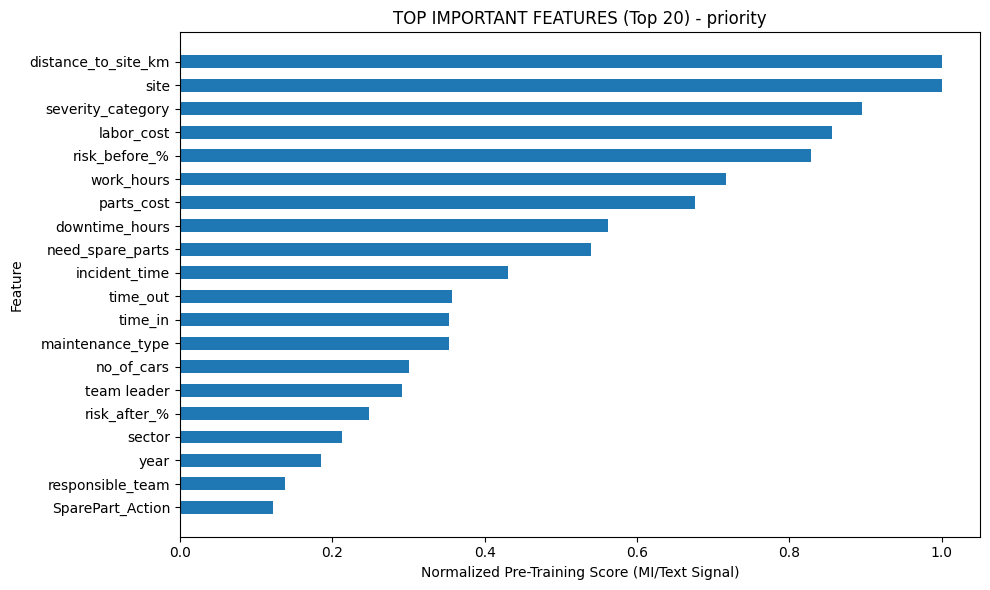


Missing y_priority : 0.0
Missing y_techcount: 0.0

✅ Preprocess factory ready

✅ Priority Classification Results
Accuracy : 0.946
Macro-F1 : 0.915
              precision    recall  f1-score   support

           1       1.00      0.97      0.98        32
           2       0.88      0.81      0.84        53
           3       0.86      0.85      0.86        67
           4       0.97      0.98      0.97       350

    accuracy                           0.95       502
   macro avg       0.93      0.90      0.91       502
weighted avg       0.95      0.95      0.95       502


✅ technicians_count Regression Results
MAE : 0.085
RMSE: 0.243
R2  : 0.42

✅ Model Evaluation Results


,Task,Target,Model,Metrics
0,Priority Classification,priority,LogisticRegression,"Accuracy=94.6%, Macro-F1=91.5%"
1,Technicians Estimation,technicians_count,RandomForestRegressor,"MAE=0.085, RMSE=0.243, R2=0.420"


📥 INPUT
-------------------------------------------------------
site                                    : r010
severity_category                       : major
fault_alarmandactivity                  : SCECO wall activity
no_technicians_at_time_of_maintance     : 2

📤 OUTPUT
-------------------------------------------------------
Predicted Priority                      : 2
Recommended Technicians Count           : 2
Raw Model Output                        : 2.07

Done ✅


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.preprocessing import LabelEncoder


# ============================================================
# 0) CONFIG
# ============================================================

DATA_PATH = "/content/data_f.xlsx"
RANDOM_STATE = 42

TARGET_PRIORITY  = "priority"
TARGET_TECHCOUNT = "technicians_count"

TEXT_COL = "fault_alarmandactivity"

# FEATURES (your requested minimal inputs)
CAT_COLS = ["site", "severity_category"]
NUM_COLS = ["no_technicians_at_time_of_maintance"]  # ⚠ leakage risk for priority

TOP_EDA_PLOTS = [
    "day", "month", "year", "priority",
    "no_technicians_at_time_of_maintance",
    "no_of_cars", "technicians_count",
    "downtime_hours", "work_hours",
    "labor_cost", "parts_cost",
    "risk_before_%", "risk_after_%"
]

HEATMAP_COLS = [
    "priority", "technicians_count", "no_technicians_at_time_of_maintance",
    "distance_to_site_km", "downtime_hours", "work_hours",
    "labor_cost", "parts_cost", "risk_before_%", "risk_after_%"
]

TOP_PRETRAIN = 20


# ============================================================
# 1) LOAD + CLEAN
# ============================================================

def clean_column_name(c: str) -> str:
    c = str(c).strip().replace("\n", " ")
    while "  " in c:
        c = c.replace("  ", " ")
    return c

def resolve_tech_at_time_column(df: pd.DataFrame) -> pd.DataFrame:
    a = "no_technicians_at_time_of_maintance"
    b = "no_technicians_at_time_of_maintenance"
    if a not in df.columns and b in df.columns:
        df = df.rename(columns={b: a})
    return df

df = pd.read_excel(DATA_PATH)
df = df.rename(columns={c: clean_column_name(c) for c in df.columns})
df = resolve_tech_at_time_column(df)
df = df.drop_duplicates()

print("✅ Loaded:", DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

if TEXT_COL not in df.columns:
    raise ValueError(f"Missing required text column: {TEXT_COL}")

# Keep only existing feature columns
CAT_COLS = [c for c in CAT_COLS if c in df.columns]
NUM_COLS = [c for c in NUM_COLS if c in df.columns]

print("\n✅ Using Features:")
print("NUM_COLS:", NUM_COLS)
print("CAT_COLS:", CAT_COLS)
print("TEXT_COL:", TEXT_COL)

display(df.head())


# ============================================================
# 2) DATASET SUMMARY (EDA TABLE)
# ============================================================

eda_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
}).reset_index(drop=True)

print("\n✅ Dataset Summary Table")
display(eda_summary)


# ============================================================
# 3) QUICK EDA PLOTS
# ============================================================

def _to_numeric(series):
    return pd.to_numeric(series, errors="coerce")

def plot_hist(ax, s, title, bins=30):
    s = _to_numeric(pd.Series(s)).dropna()
    if len(s) == 0:
        ax.axis("off")
        return
    ax.hist(
        s,
        bins=bins,
        linewidth=0.1,
        edgecolor="black"
    )
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="both", labelsize=8)

def plot_bar_counts(ax, s, title, rotate=45):
    s = pd.Series(s).dropna()
    s_num = pd.to_numeric(s, errors="coerce")

    if s_num.notna().sum() > 0:
        counts = s_num.dropna().value_counts().sort_index()
        labels = counts.index.astype(str).tolist()
        values = counts.values
    else:
        counts = s.astype(str).value_counts().head(20)
        labels = counts.index.astype(str).tolist()
        values = counts.values

    ax.bar(
        range(len(labels)),
        values,
        width=0.1,
        linewidth=0.4,
        edgecolor="black"
    )
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis="both", labelsize=8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=rotate, ha="right")

cols_exist = [c for c in TOP_EDA_PLOTS if c in df.columns]
n = len(cols_exist)

rows, cols = 3, 4
fig, axes = plt.subplots(rows, cols, figsize=(14, 7))
plt.suptitle("EDA Snapshot", fontsize=14)

k = 0
for r in range(rows):
    for c in range(cols):
        ax = axes[r, c]
        if k >= n:
            ax.axis("off")
            continue
        col = cols_exist[k]
        unique_vals = df[col].nunique(dropna=True)
        if unique_vals <= 15:
            plot_bar_counts(ax, df[col], col)
        else:
            plot_hist(ax, df[col], col)
        k += 1

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# ============================================================
# 4) CORRELATION HEATMAP (WITH VALUES)
# ============================================================

def corr_heatmap_with_values(df_in: pd.DataFrame, title: str):
    corr = df_in.corr(numeric_only=True)
    cols = corr.columns.tolist()

    plt.figure(figsize=(11, 7))
    im = plt.imshow(corr, vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
    plt.yticks(range(len(cols)), cols)

    for i in range(len(cols)):
        for j in range(len(cols)):
            v = corr.iloc[i, j]
            if not np.isnan(v):
                plt.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)

    plt.title(title)
    plt.tight_layout()
    plt.show()

heat_cols = [c for c in HEATMAP_COLS if c in df.columns]
df_heat = df[heat_cols].apply(pd.to_numeric, errors="coerce")
corr_heatmap_with_values(df_heat, "Correlation Heatmap (with values)")


# ============================================================
# 5) TOP IMPORTANT FEATURES
# ============================================================

def to_numeric_if_possible(s: pd.Series) -> pd.Series:
    if s.dtype == "object":
        s2 = pd.to_numeric(
            s.astype(str).str.replace(",", "", regex=False).str.strip(),
            errors="coerce"
        )
        if s2.notna().mean() > 0.5:
            return s2
    return s

df_pre = df.copy()

# ensure targets numeric for ranking
df_pre[TARGET_TECHCOUNT] = pd.to_numeric(df_pre.get(TARGET_TECHCOUNT), errors="coerce")
df_pre[TARGET_PRIORITY]  = pd.to_numeric(df_pre.get(TARGET_PRIORITY),  errors="coerce")

# ensure text exists
df_pre[TEXT_COL] = df_pre[TEXT_COL].fillna("").astype(str)

# convert other cols when possible
for col in df_pre.columns:
    df_pre[col] = to_numeric_if_possible(df_pre[col])

# define candidate features (exclude targets + id)
exclude_pre = {TARGET_TECHCOUNT, TARGET_PRIORITY, "ticket_number"}
feature_cols_pre = [c for c in df_pre.columns if c not in exclude_pre]

num_cols_pre = [c for c in feature_cols_pre if (c != TEXT_COL and pd.api.types.is_numeric_dtype(df_pre[c]))]
cat_cols_pre = [c for c in feature_cols_pre if (c != TEXT_COL and not pd.api.types.is_numeric_dtype(df_pre[c]))]

print("\n✅ Pre-training candidates:")
print("Numeric cols:", len(num_cols_pre))
print("Categorical cols:", len(cat_cols_pre))
print("Text col:", TEXT_COL)

def rank_features_pretraining(df_in: pd.DataFrame, target: str, task: str, top_k: int = 20):
    """
    task: 'reg' or 'clf'
    Returns: DataFrame with (feature, score, type)
    """
    assert task in {"reg", "clf"}

    data = df_in.dropna(subset=[target]).copy()
    y = data[target].values

    scores = []

    # ---- (A) Numeric -> MI (+ correlation for regression)
    if len(num_cols_pre) > 0:
        X_num = data[num_cols_pre].copy()
        X_num = X_num.fillna(X_num.median(numeric_only=True))

        if task == "reg":
            mi = mutual_info_regression(X_num, y, random_state=42)
            corr = []
            for c in num_cols_pre:
                v = X_num[c].values
                corr.append(abs(np.corrcoef(v, y)[0, 1]) if np.std(v) > 0 else 0.0)
            corr = np.array(corr)
        else:
            y_int = pd.Series(y).astype(int).values
            mi = mutual_info_classif(X_num, y_int, random_state=42)
            corr = np.zeros(len(num_cols_pre))

        mi_n = (mi - mi.min()) / (mi.max() - mi.min() + 1e-9)

        if task == "reg":
            corr_n = (corr - corr.min()) / (corr.max() - corr.min() + 1e-9)
            combined_num = 0.7 * mi_n + 0.3 * corr_n
        else:
            combined_num = mi_n

        for c, sc in zip(num_cols_pre, combined_num):
            scores.append((c, float(sc), "numeric"))

    # ---- (B) Categorical -> LabelEncode then MI
    if len(cat_cols_pre) > 0:
        for c in cat_cols_pre:
            s = data[c].fillna("missing").astype(str)
            le = LabelEncoder()
            x = le.fit_transform(s).reshape(-1, 1)

            if task == "reg":
                mi = mutual_info_regression(x, y, random_state=42)[0]
            else:
                y_int = pd.Series(y).astype(int).values
                mi = mutual_info_classif(x, y_int, random_state=42)[0]

            scores.append((c, float(mi), "categorical"))

    # ---- (C) Text -> TF-IDF signal strength
    if TEXT_COL in data.columns:
        text = data[TEXT_COL].fillna("").astype(str).values
        tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
        X_text = tfidf.fit_transform(text)
        text_strength = float(np.mean(X_text.mean(axis=1)))
        scores.append((TEXT_COL, text_strength, "text"))

    out = pd.DataFrame(scores, columns=["feature", "raw_score", "type"])

    # normalize within each type
    out["score"] = 0.0
    for t in out["type"].unique():
        m = out.loc[out["type"] == t, "raw_score"]
        out.loc[out["type"] == t, "score"] = (m - m.min()) / (m.max() - m.min() + 1e-9)

    out = out.sort_values("score", ascending=False).head(top_k).reset_index(drop=True)
    return out[["feature", "score", "type"]]

top20_pre_tech = rank_features_pretraining(df_pre, TARGET_TECHCOUNT, task="reg", top_k=TOP_PRETRAIN)
top20_pre_prio = rank_features_pretraining(df_pre, TARGET_PRIORITY,  task="clf", top_k=TOP_PRETRAIN)

print("\n===== TOP 20 (TOP IMPORTANT FEATURES) for technicians_count =====")
display(top20_pre_tech)

print("\n===== TOP 20 (TOP IMPORTANT FEATURES) for priority =====")
display(top20_pre_prio)

def plot_top_features(df_rank: pd.DataFrame, title: str, xlabel: str):
    df_plot = df_rank.sort_values("score", ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(df_plot["feature"], df_plot["score"], height=0.55)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

plot_top_features(
    top20_pre_tech,
    title=f"TOP IMPORTANT FEATURES (Top {len(top20_pre_tech)}) - technicians_count",
    xlabel="Normalized Pre-Training Score (MI/Correlation/Text Signal)"
)

plot_top_features(
    top20_pre_prio,
    title=f"TOP IMPORTANT FEATURES (Top {len(top20_pre_prio)}) - priority",
    xlabel="Normalized Pre-Training Score (MI/Text Signal)"
)


# ============================================================
# 6) BUILD TARGETS
# ============================================================

df["y_priority"]  = pd.to_numeric(df.get(TARGET_PRIORITY), errors="coerce")
df["y_techcount"] = pd.to_numeric(df.get(TARGET_TECHCOUNT), errors="coerce")

print("\nMissing y_priority :", round(df["y_priority"].isna().mean(), 3))
print("Missing y_techcount:", round(df["y_techcount"].isna().mean(), 3))


# ============================================================
# 7) PREPROCESS FACTORY (IMPORTANT FIX)
#    Each model must have its OWN preprocess instance
# ============================================================

def coerce_numeric_2d(X):
    X = pd.DataFrame(X).copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    return X

def make_preprocess(NUM_COLS, CAT_COLS, TEXT_COL):
    num_pipe = Pipeline(steps=[
        ("to_num", FunctionTransformer(coerce_numeric_2d, validate=False)),
        ("imputer", SimpleImputer(strategy="median")),
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ])

    txt_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("to_1d", FunctionTransformer(lambda x: np.ravel(x).astype(str), validate=False)),
        ("tfidf", TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, NUM_COLS),
            ("cat", cat_pipe, CAT_COLS),
            ("txt", txt_pipe, [TEXT_COL]),
        ],
        remainder="drop"
    )

print("\n✅ Preprocess factory ready")


# ============================================================
# 8) MODEL A — Priority Classification (LogisticRegression)
# ============================================================

data_p = df.dropna(subset=["y_priority"]).copy()
X_p = data_p[NUM_COLS + CAT_COLS + [TEXT_COL]]
y_p = data_p["y_priority"].astype(int)

strat = y_p if y_p.value_counts().min() >= 2 else None

Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_p, y_p, test_size=0.2, random_state=RANDOM_STATE, stratify=strat
)

priority_model = Pipeline(steps=[
    ("prep", make_preprocess(NUM_COLS, CAT_COLS, TEXT_COL)),
    ("model", LogisticRegression(max_iter=3000, n_jobs=-1))
])

priority_model.fit(Xp_train, yp_train)
pred_p = priority_model.predict(Xp_test)

print("\n==============================")
print("✅ Priority Classification Results")
print("==============================")
print("Accuracy :", round(accuracy_score(yp_test, pred_p), 3))
print("Macro-F1 :", round(f1_score(yp_test, pred_p, average="macro"), 3))
print(classification_report(yp_test, pred_p))


# ============================================================
# 9) MODEL B — technicians_count Regression (RandomForest)
# ============================================================

data_t = df.dropna(subset=["y_techcount"]).copy()
X_t = data_t[NUM_COLS + CAT_COLS + [TEXT_COL]]
y_t = data_t["y_techcount"]

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_t, y_t, test_size=0.2, random_state=RANDOM_STATE
)

tech_count_model = Pipeline(steps=[
    ("prep", make_preprocess(NUM_COLS, CAT_COLS, TEXT_COL)),
    ("model", RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2
    ))
])

tech_count_model.fit(Xt_train, yt_train)
pred_t = tech_count_model.predict(Xt_test)

rmse = float(np.sqrt(mean_squared_error(yt_test, pred_t)))

print("\n==============================")
print("✅ technicians_count Regression Results")
print("==============================")
print("MAE :", round(mean_absolute_error(yt_test, pred_t), 3))
print("RMSE:", round(rmse, 3))
print("R2  :", round(r2_score(yt_test, pred_t), 3))


# ============================================================
# 10) RESULTS TABLE (FOR SLIDES)
# ============================================================

results_table = pd.DataFrame([
    {
        "Task": "Priority Classification",
        "Target": TARGET_PRIORITY,
        "Model": "LogisticRegression",
        "Metrics": f"Accuracy={accuracy_score(yp_test, pred_p)*100:.1f}%, Macro-F1={f1_score(yp_test, pred_p, average='macro')*100:.1f}%"
    },
    {
        "Task": "Technicians Estimation",
        "Target": TARGET_TECHCOUNT,
        "Model": "RandomForestRegressor",
        "Metrics": f"MAE={mean_absolute_error(yt_test, pred_t):.3f}, RMSE={rmse:.3f}, R2={r2_score(yt_test, pred_t):.3f}"
    }
])

print("\n✅ Model Evaluation Results")
display(results_table)


# ============================================================
# 11) SAFE PREDICTION API + DEMO
# ============================================================

TRAIN_COLS = (NUM_COLS + CAT_COLS + [TEXT_COL])

def predict_one(site, severity_category, alarm_text, no_tech_at_time):
    site = str(site).lower().strip()
    severity_category = str(severity_category).lower().strip()
    alarm_text = str(alarm_text)

    row = {
        "site": site,
        "severity_category": severity_category,
        TEXT_COL: alarm_text,
        "no_technicians_at_time_of_maintance": no_tech_at_time
    }

    X_new = pd.DataFrame([row]).reindex(columns=TRAIN_COLS)

    pri = int(priority_model.predict(X_new)[0])
    tech_raw = float(tech_count_model.predict(X_new)[0])
    tech_final = int(round(max(1, tech_raw)))

    return {
        "predicted_priority": pri,
        "predicted_technicians_count": tech_final,
        "raw_technicians_count": tech_raw
    }

def show_result(input_dict, output_dict):
    print("=" * 55)
    print("📥 INPUT")
    print("-" * 55)
    for k, v in input_dict.items():
        print(f"{k:40s}: {v}")

    print("\n📤 OUTPUT")
    print("-" * 55)
    print(f"{'Predicted Priority':40s}: {output_dict['predicted_priority']}")
    print(f"{'Recommended Technicians Count':40s}: {output_dict['predicted_technicians_count']}")
    print(f"{'Raw Model Output':40s}: {output_dict['raw_technicians_count']:.2f}")
    print("=" * 55)

# ---- Demo Example
input_data = {
    "site": "r010",
    "severity_category": "major",
    "fault_alarmandactivity": "SCECO wall activity",
    "no_technicians_at_time_of_maintance": 2
}

output_data = predict_one(
    site=input_data["site"],
    severity_category=input_data["severity_category"],
    alarm_text=input_data["fault_alarmandactivity"],
    no_tech_at_time=input_data["no_technicians_at_time_of_maintance"]
)

show_result(input_data, output_data)

print("\nDone ✅")
